In [1]:
# https://pygad.readthedocs.io/en/latest/kerasga.html

!pip install pygad

import tensorflow.keras
import pygad.kerasga
import numpy
import pygad


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 3.6 MB/s eta 0:00:00


In [19]:
def fitness_func(ga_instance, solution, sol_idx):
    global data_inputs, data_outputs, keras_ga, model

    predictions = pygad.kerasga.predict(model=model,
                                        solution=solution,
                                        data=data_inputs)

    cce = tensorflow.keras.losses.CategoricalCrossentropy()
    solution_fitness = 1.0 / (cce(data_outputs, predictions).numpy() + 0.00000001)

    return solution_fitness

def on_generation(ga_instance): # callback
    print(f"Generation = {ga_instance.generations_completed}")
    print(f"Fitness    = {ga_instance.best_solution()[1]}")

In [5]:
# Build the keras model using the functional API.
input_layer = tensorflow.keras.layers.Input(shape=(100, 100, 3))
conv_layer1 = tensorflow.keras.layers.Conv2D(filters=5,
                                             kernel_size=7,
                                             activation="relu")(input_layer)
max_pool1 = tensorflow.keras.layers.MaxPooling2D(pool_size=(5,5),
                                                 strides=5)(conv_layer1)
conv_layer2 = tensorflow.keras.layers.Conv2D(filters=3,
                                             kernel_size=3,
                                             activation="relu")(max_pool1)
flatten_layer  = tensorflow.keras.layers.Flatten()(conv_layer2)
dense_layer = tensorflow.keras.layers.Dense(15, activation="relu")(flatten_layer)
output_layer = tensorflow.keras.layers.Dense(4, activation="softmax")(dense_layer)

model = tensorflow.keras.Model(inputs=input_layer, outputs=output_layer)


In [6]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 100, 100, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 94, 94, 5)           │             740 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 18, 18, 5)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 16, 16, 3)           │             138 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 768)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 15)                  │          11,535 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 4)                   │              64 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 12,477 (48.74 KB)

 Trainable params: 12,477 (48.74 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# Create an instance of the pygad.kerasga.KerasGA class to build the initial population.
keras_ga = pygad.kerasga.KerasGA(model=model,
                                 num_solutions=10)


In [21]:
# descargar los .npy donde están las imágenes y sus etiquetas
!wget https://github.com/palasatenea66/DATASETS/blob/main/dataset_inputs.npy?raw=true -O dataset_inputs.npy
!wget https://github.com/palasatenea66/DATASETS/blob/main/dataset_outputs.npy?raw=true -O dataset_outputs.npy

--2025-02-27 23:23:43--  https://github.com/palasatenea66/DATASETS/blob/main/dataset_inputs.npy?raw=true
Resolving github.com (github.com)... 140.82.112.3
Connecting to github.com (github.com)|140.82.112.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://github.com/palasatenea66/DATASETS/raw/refs/heads/main/dataset_inputs.npy [following]
--2025-02-27 23:23:43--  https://github.com/palasatenea66/DATASETS/raw/refs/heads/main/dataset_inputs.npy
Reusing existing connection to github.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/palasatenea66/DATASETS/refs/heads/main/dataset_inputs.npy [following]
--2025-02-27 23:23:43--  https://raw.githubusercontent.com/palasatenea66/DATASETS/refs/heads/main/dataset_inputs.npy
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.110.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com

In [22]:
!ls

dataset_inputs.npy  dataset_outputs.npy  sample_data


In [23]:
# Data inputs
data_inputs = numpy.load("dataset_inputs.npy")        # https://github.com/ahmedfgad/NumPyCNN/blob/master/dataset_inputs.npy

# Data outputs
data_outputs = numpy.load("dataset_outputs.npy")      # https://github.com/ahmedfgad/NumPyCNN/blob/master/dataset_outputs.npy
data_outputs = tensorflow.keras.utils.to_categorical(data_outputs)

In [9]:
data_outputs

array([[1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],


In [10]:
data_outputs.shape

(80, 4)

In [11]:
data_inputs.shape

(80, 100, 100, 3)

In [12]:
# Prepare the PyGAD parameters. Check the documentation for more information: https://pygad.readthedocs.io/en/latest/pygad.html#pygad-ga-class
num_generations = 200 # Number of generations.
num_parents_mating = 5 # Number of solutions to be selected as parents in the mating pool.
initial_population = keras_ga.population_weights # Initial population of network weights.


In [13]:
# Create an instance of the pygad.GA class
ga_instance = pygad.GA(num_generations=num_generations,
                       num_parents_mating=num_parents_mating,
                       initial_population=initial_population,
                       fitness_func=fitness_func,
                       on_generation=on_generation)

# Start the genetic algorithm evolution.
ga_instance.run()

Generation = 1
Fitness    = 0.12408413948044919
Generation = 2
Fitness    = 0.12408413948044919
Generation = 3
Fitness    = 0.12408413948044919
Generation = 4
Fitness    = 0.12408413948044919
Generation = 5
Fitness    = 0.12408413948044919
Generation = 6
Fitness    = 0.14181043550608455
Generation = 7
Fitness    = 0.14181043550608455
Generation = 8
Fitness    = 0.14181043550608455
Generation = 9
Fitness    = 0.15857848935290056
Generation = 10
Fitness    = 0.15857848935290056
Generation = 11
Fitness    = 0.15857848935290056
Generation = 12
Fitness    = 0.16024121979883948
Generation = 13
Fitness    = 0.19024587438225643
Generation = 14
Fitness    = 0.19960265065043944
Generation = 15
Fitness    = 0.21978995340210825
Generation = 16
Fitness    = 0.21978995340210825
Generation = 17
Fitness    = 0.72793879118297
Generation = 18
Fitness    = 0.72793879118297
Generation = 19
Fitness    = 0.9328790479790069
Generation = 20
Fitness    = 0.9328790479790069
Generation = 21
Fitness    = 0.932879

/usr/local/lib/python3.11/dist-packages/pygad/visualize/plot.py:120: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  matplt.legend()


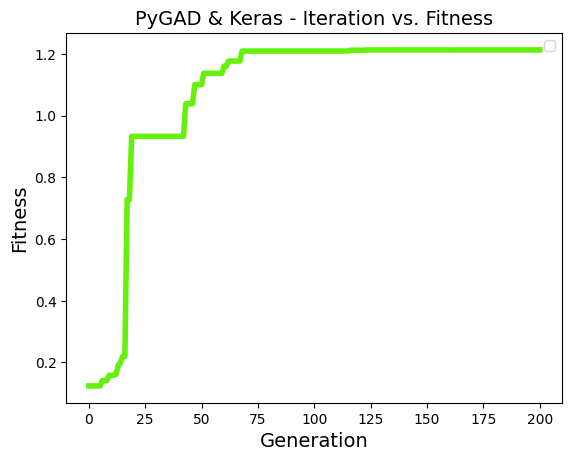

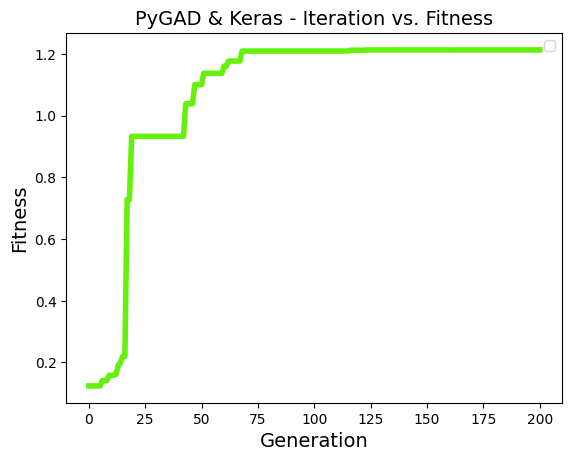

In [14]:

# After the generations complete, some plots are showed that summarize how the outputs/fitness values evolve over generations.
ga_instance.plot_fitness(title="PyGAD & Keras - Iteration vs. Fitness", linewidth=4)


In [15]:
# Returning the details of the best solution.
solution, solution_fitness, solution_idx = ga_instance.best_solution()
print(f"Fitness value of the best solution = {solution_fitness}")
print(f"Index of the best solution : {solution_idx}")


Fitness value of the best solution = 1.2130794995006267
Index of the best solution : 0


In [16]:
# Make predictions based on the best solution.
predictions = pygad.kerasga.predict(model=model,
                                    solution=solution,
                                    data=data_inputs)
#print(f"Predictions : \n{predictions}")


In [17]:

# Calculate the categorical crossentropy for the trained model.
cce = tensorflow.keras.losses.CategoricalCrossentropy()
print(f"Categorical Crossentropy : {cce(data_outputs, predictions).numpy()}")


Categorical Crossentropy : 0.8243482708930969


In [18]:

# Calculate the classification accuracy for the trained model.
ca = tensorflow.keras.metrics.CategoricalAccuracy()
ca.update_state(data_outputs, predictions)
accuracy = ca.result().numpy()
print(f"Accuracy : {accuracy}")

Accuracy : 0.5
